<a href="https://colab.research.google.com/github/TanyaGupta37/ML-Lab/blob/main/Lab8_DecisionTreeipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("winequality-red.csv", sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [7]:
df['target'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [8]:
X = df.drop(['quality','target'], axis=1)
y = df['target']

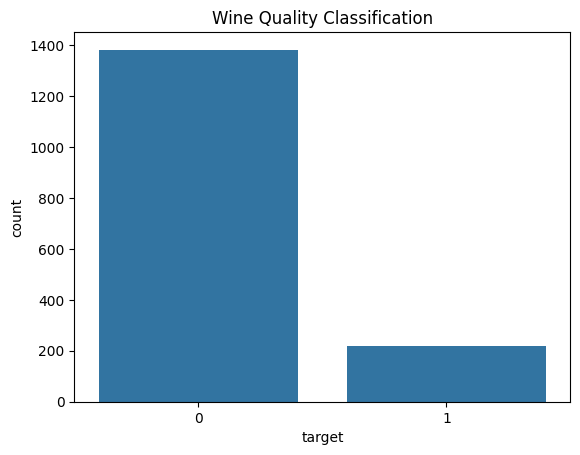

In [9]:
sns.countplot(x=y)
plt.title("Wine Quality Classification")
plt.show()

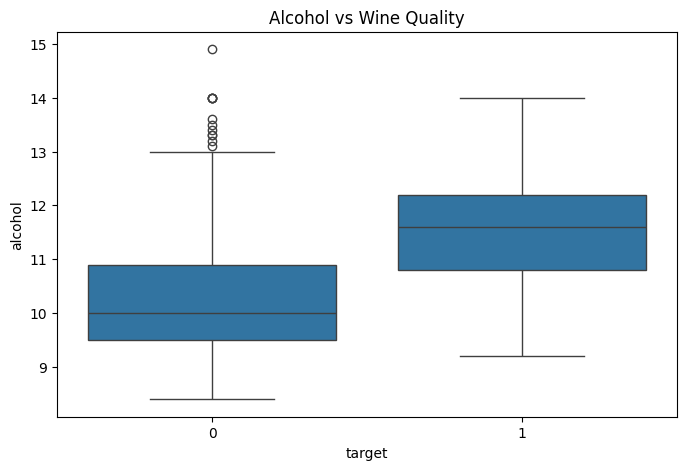

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x=y, y=df['alcohol'])
plt.title("Alcohol vs Wine Quality")
plt.show()

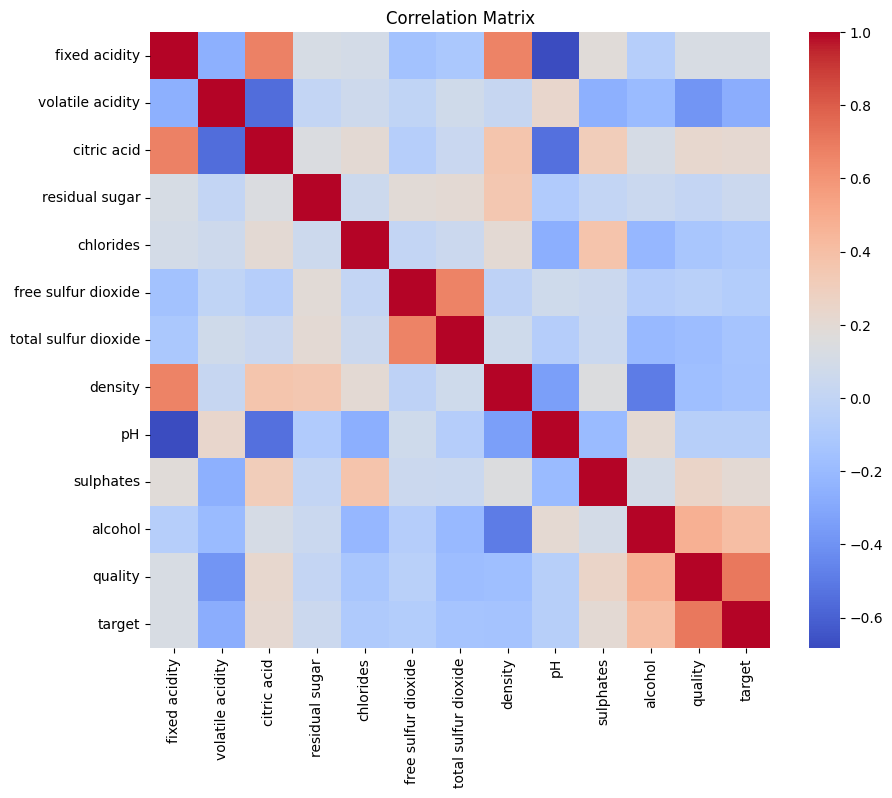

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [13]:
predictions = dtree.predict(X_test)

In [14]:
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[254  19]
 [ 20  27]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       273
           1       0.59      0.57      0.58        47

    accuracy                           0.88       320
   macro avg       0.76      0.75      0.75       320
weighted avg       0.88      0.88      0.88       320



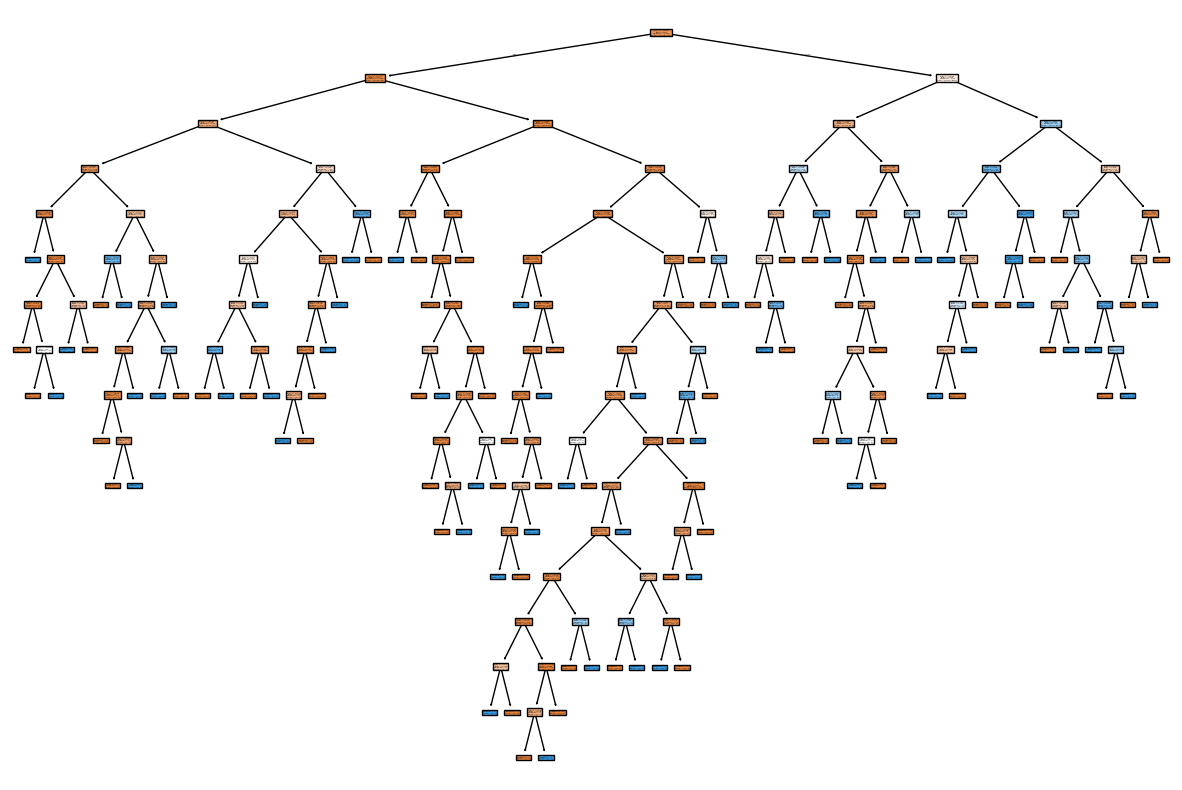

In [15]:
from sklearn import tree

plt.figure(figsize=(15,10))
tree.plot_tree(dtree, filled=True)
plt.show()

In [16]:
importance = pd.Series(dtree.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
alcohol,0.217171
volatile acidity,0.142007
sulphates,0.132942
total sulfur dioxide,0.104706
free sulfur dioxide,0.078594
fixed acidity,0.063485
residual sugar,0.061160
chlorides,0.058368
citric acid,0.051839
pH,0.048251


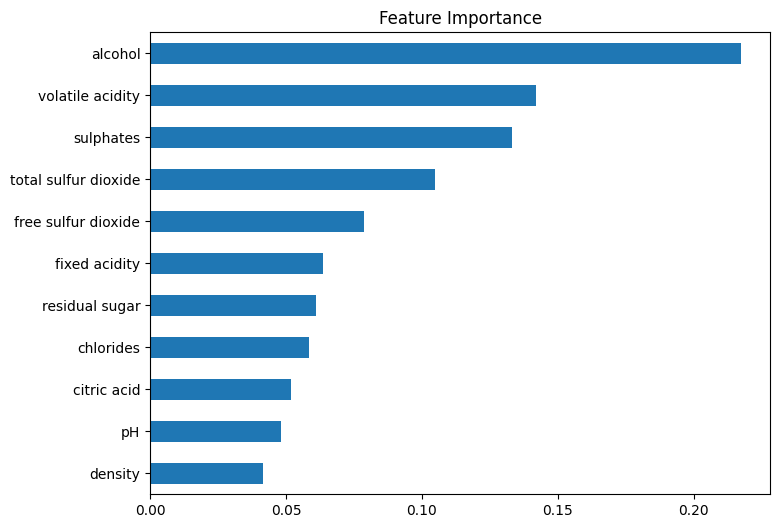

In [20]:
importance = pd.Series(dtree.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [17]:
dtree2 = DecisionTreeClassifier(max_depth=4)
dtree2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [18]:
predictions2 = dtree2.predict(X_test)

print(confusion_matrix(y_test, predictions2))
print(classification_report(y_test, predictions2))

[[264   9]
 [ 31  16]]
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       273
           1       0.64      0.34      0.44        47

    accuracy                           0.88       320
   macro avg       0.77      0.65      0.69       320
weighted avg       0.86      0.88      0.86       320

